### Speech Analysis and Transcription Pipeline

This script demonstrates a complete speech processing workflow from audio capture to transcription and visualization. It records speech, analyzes its acoustic properties, and converts it to text using multilingual ASR capabilities.

Key Libraries Used:

    sounddevice: Audio recording and playback

    numpy: Signal processing and array operations

    scipy.signal: Spectrogram computation

    matplotlib: Visualization of waveform and spectrogram

    whisper: Speech-to-text transcription

    soundfile: Temporary audio file handling

Code Logic and Flow

The pipeline:

    Records 3 seconds of 16kHz speech

    Plays back the recording for verification

    Visualizes waveform and spectrogram

    Transcribes speech to text using Whisper

    Supports multiple languages (Hindi/English)

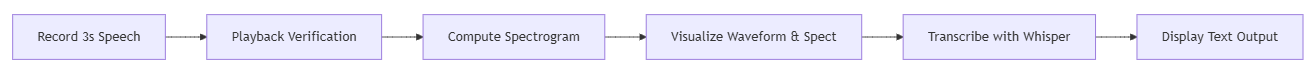

Step-by-Step Code Breakdown

1. Audio Recording

    Captures 16kHz mono audio for 3 seconds

    Uses system's default microphone

    Returns audio as flattened NumPy array

2. Audio Playback

    Plays recorded audio through default speakers

    Provides immediate quality verification

3. Acoustic Analysis

    Waveform Visualization:

        Plots amplitude vs. time

        Shows raw speech signal characteristics

    Spectrogram Computation:

        Uses 256-sample Hamming windows with 50% overlap

        Converts to decibel scale for perceptual relevance

        Visualizes frequency content over time

4. Speech Transcription

    Saves audio to temporary WAV file

    Loads Whisper-base model (multilingual support)

    Transcribes with language specification (default: Hindi)

    Handles file cleanup automatically

5. Output Presentation

    Saves visualization as PNG file

    Displays transcription in console

    Supports language switching via parameter

Connecting to Lecture Concepts

This implementation demonstrates:

    Time-Frequency Analysis: Spectrograms reveal phonetic content

    Sample Rate Importance: 16kHz optimal for speech processing

    Multilingual ASR: Whisper's cross-lingual capabilities

    Acoustic Properties: Waveform shows amplitude variations

    Temporal Resolution: 50% overlap maintains phoneme boundaries

    Formant Visualization: Spectrogram shows vowel resonances

    Practical Debugging: Playback verifies recording quality

    Temporary File Handling: Efficient memory management

    Research Foundation: Standard pipeline for speech analysis

    Perceptual Scaling: dB conversion mimics human hearing

    Phoneme Identification: Spectrogram patterns map to speech sounds

    End-to-End Workflow: From physical signal to semantic text

In [2]:
!pip install numpy scipy matplotlib sounddevice

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.1 MB 6.3 MB/s eta 0:00:02
   ------ --------------------------------- 1.3/8.1 MB 3.2 MB/s eta 0:00:03
   -------------- ------------------------- 2.9/8.1 MB 4.4 MB/s eta 0:00:02
   ------------------ --------------------- 3.7/8.1 MB 4.3 MB/s eta 0:00:02
   ---------------------- ----------------- 4.5/8.1 MB 4.2 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.1 MB 4.1 MB/s eta 0:00:01
   ------------------------------- -------- 6.3/8.1 MB 4.1 MB/s eta 0:00:01
   ----------------------------------- ---- 7.1/8.1 MB 4.1 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.1 MB 4.1 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 4.0 MB/s eta 0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.2 MB

Recording for 3 seconds...
Playing back the recorded audio...


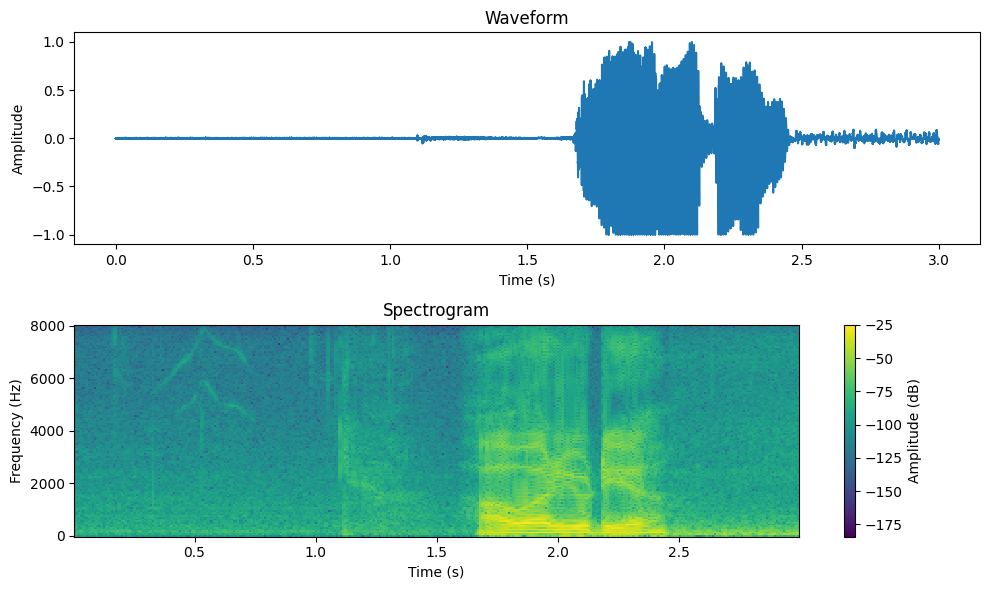

Loading Whisper model...
Transcribing audio...

Transcribed Text:
 How are you dear?


In [2]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
import sounddevice as sd
import soundfile as sf
import whisper
import tempfile
import os

# Parameters
sample_rate = 16000  # Hz
duration = 3  # seconds

# Function to record audio
def record_audio():
    """Record audio from microphone."""
    print(f"Recording for {duration} seconds...")
    audio = sd.rec(int(duration * sample_rate), samplerate=sample_rate, channels=1)
    sd.wait()  # Wait until recording is finished
    audio = audio.flatten()
    return audio

# Function to play audio
def play_audio(audio, sample_rate):
    """Play back the recorded audio."""
    print("Playing back the recorded audio...")
    sd.play(audio, samplerate=sample_rate)
    sd.wait()  # Wait until playback is finished

# Function to compute and plot spectrogram
def plot_spectrogram(audio, sample_rate):
    """Compute and visualize waveform and spectrogram."""
    # Plot waveform
    plt.figure(figsize=(10, 6))
    plt.subplot(2, 1, 1)
    time = np.linspace(0, len(audio) / sample_rate, num=len(audio))
    plt.plot(time, audio)
    plt.title("Waveform")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    
    # Compute spectrogram
    frequencies, times, Sxx = signal.spectrogram(audio, fs=sample_rate, nperseg=256, noverlap=128)
    
    # Plot spectrogram
    plt.subplot(2, 1, 2)
    plt.pcolormesh(times, frequencies, 10 * np.log10(Sxx), shading='auto')
    plt.title("Spectrogram")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.colorbar(label="Amplitude (dB)")
    plt.tight_layout()
    
    # Save and show plot
    plt.savefig("waveform_spectrogram.png")
    plt.show()

# Function to transcribe audio using Whisper
def transcribe_audio(audio, sample_rate, language="hi"):
    """Transcribe the recorded audio using Whisper."""
    # Save audio to a temporary WAV file
    with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as tmpfile:
        sf.write(tmpfile.name, audio, sample_rate)
        tmpfile_path = tmpfile.name

    # Load Whisper model
    print("Loading Whisper model...")
    model = whisper.load_model("base")
    print("Transcribing audio...")
    result = model.transcribe(tmpfile_path, language=language)
    transcript = result["text"]

    # Clean up temp file
    os.remove(tmpfile_path)
    return transcript

# Main function
def main():
    # Record audio
    audio = record_audio()
    
    # Play back the recorded audio
    play_audio(audio, sample_rate)
    
    # Plot waveform and spectrogram
    plot_spectrogram(audio, sample_rate)
    
    # Transcribe and display as text
    transcript = transcribe_audio(audio, sample_rate, language="en")  # Change to "en" for English
    print("\nTranscribed Text:")
    print(transcript)

if __name__ == "__main__":
    main()